In [1]:
%cd /Users/kaitlinzareno/Downloads/csci535_project/csci535-project

/Users/kaitlinzareno/Downloads/csci535_project/csci535-project


In [2]:
import pickle
from pathlib import Path
from itertools import product
import numpy as np
import pandas as pd
import torch

from utils.computations import pairwise_diffs_p2p, cosine_distance, l2_distance, cosine_similarity, normalized_l2_distance


In [3]:
DEEP_EMB_ROOT = Path("/Users/kaitlinzareno/Downloads/csci535_project/deep_embeddings")
MODEL = "whisper"
metric_fcn = normalized_l2_distance

In [4]:
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

In [5]:
example_path = DEEP_EMB_ROOT / "V00_S1132_I00000333" / f"moi_embeddings_{MODEL}.pkl"
data = load_pickle(example_path)

data.keys()

dict_keys(['session_name', 'model', 'turns', 'moi_events'])

### helper code to properly format dictionaries

In [6]:
def turn_to_speaker_dict(turn):
    """
    Convert a single stored turn dict into:
      {speaker: embedding}
    """
    if turn is None:
        return None

    emb = turn["embedding"]
    if not isinstance(emb, torch.Tensor):
        emb = torch.tensor(emb)

    return {turn["speaker"]: emb}

def turns_to_speaker_dict(turns, agg="mean"):
    """
    Convert a list of stored turn dicts into:
      {speaker: aggregated_embedding}

    Usually during may have one or more overlapping turns.
    """
    if turns is None or len(turns) == 0:
        return None

    speaker_to_embeds = {}

    for turn in turns:
        spk = turn["speaker"]
        emb = turn["embedding"]
        if not isinstance(emb, torch.Tensor):
            emb = torch.tensor(emb)

        speaker_to_embeds.setdefault(spk, []).append(emb)

    out = {}
    for spk, embeds in speaker_to_embeds.items():
        stack = torch.stack(embeds, dim=0)
        if agg == "mean":
            out[spk] = stack.mean(dim=0)
        elif agg == "sum":
            out[spk] = stack.sum(dim=0)
        else:
            raise ValueError(f"Unknown agg={agg}")

    return out

def event_to_window_dicts(event_record, agg="mean"):
    """
    Returns:
      pre_dict, during_dict, post_dict
    in the format expected by pairwise_diffs_p2p
    """
    pre_dict = turn_to_speaker_dict(event_record["pre"])
    during_dict = turns_to_speaker_dict(event_record["during"], agg=agg)
    post_dict = turn_to_speaker_dict(event_record["post"])

    return pre_dict, during_dict, post_dict

## Analyze Single Event Alignment

In [7]:
def analyze_single_event_alignment(
    event_record,
    metric_fcn=metric_fcn,
    agg="mean"
):
    meta = event_record["event_metadata"]

    pre_dict, during_dict, post_dict = event_to_window_dicts(event_record, agg=agg)

    pre_during = None
    during_post = None

    if pre_dict is not None and during_dict is not None:
        pre_during = pairwise_diffs_p2p(
            (pre_dict, during_dict),
            embedding=True,
            metric_fcn=metric_fcn
        )

    if during_dict is not None and post_dict is not None:
        during_post = pairwise_diffs_p2p(
            (during_dict, post_dict),
            embedding=True,
            metric_fcn=metric_fcn
        )

    moi_role = (
        "annotated_is_speaker"
        if meta.get("annotated_is_speaker", False)
        else "annotated_is_listener"
    )

    return {
        "event_metadata": meta,
        "moi_role": moi_role,
        "annotated_is_speaker": meta.get("annotated_is_speaker", False),
        "annotated_is_listener": meta.get("annotated_is_listener", False),
        "pre_during": pre_during,
        "during_post": during_post,
    }

def flatten_event_alignment(event_result):
    rows = []
    meta = event_result["event_metadata"]

    phase_name_map = {
        "pre_during": "pre_moi_alignment",
        "during_post": "post_moi_alignment",
    }

    for raw_phase_name in ["pre_during", "during_post"]:
        phase_result = event_result[raw_phase_name]

        if phase_result is None:
            continue

        pretty_phase_name = phase_name_map[raw_phase_name]

        for pair_id, diff in phase_result:
            rows.append({
                "session_name": meta["session_name"],
                "event_idx": meta["event_idx"],
                "event_speaker": meta["event_speaker"],
                "annotated_participant": meta["annotated_participant"],
                "other_participant": meta.get("other_participant"),
                "annotation": meta.get("annotation"),
                "valence": meta.get("valence"),
                "start_moi": meta["start_moi"],
                "end_moi": meta["end_moi"],
                "annotated_is_speaker": event_result["annotated_is_speaker"],
                "annotated_is_listener": event_result["annotated_is_listener"],
                "moi_role": event_result["moi_role"],
                "actual_during_speaker": meta.get("actual_during_speaker"),
                "proper_turn_switches": meta.get("proper_turn_switches"),
                "phase": pretty_phase_name,
                "pair_id": pair_id,
                "alignment_score": diff,
            })

    return rows

## Obtain Session Alignment

In [8]:
def analyze_session_alignment(
    session_data,
    metric_fcn=l2_distance,
    agg="mean"
):
    rows = []

    for event_record in session_data["moi_events"]:
        event_result = analyze_single_event_alignment(
            event_record,
            metric_fcn=metric_fcn,
            agg=agg
        )
        rows.extend(flatten_event_alignment(event_result))

    return pd.DataFrame(rows)

In [9]:
def q1(series):
    series = pd.Series(series).dropna()
    if len(series) == 0:
        return np.nan
    return series.quantile(0.25)


def q3(series):
    series = pd.Series(series).dropna()
    if len(series) == 0:
        return np.nan
    return series.quantile(0.75)


def iqr(series):
    series = pd.Series(series).dropna()
    if len(series) == 0:
        return np.nan
    return series.quantile(0.75) - series.quantile(0.25)

In [10]:
df_session = analyze_session_alignment(
    session_data=data,
    metric_fcn=metric_fcn,   # or cosine_similarity_score if you switch to similarity
    agg="mean"
)

df_session.head()

,session_name,event_idx,event_speaker,annotated_participant,other_participant,annotation,valence,start_moi,end_moi,annotated_is_speaker,annotated_is_listener,moi_role,actual_during_speaker,proper_turn_switches,phase,pair_id,alignment_score
0,V00_S1132_I00000333,0,P0737,P1093,P0737,None,None,26,28,False,True,annotated_is_listener,P0737,False,post_moi_alignment,P0737-P1093,0.269084
1,V00_S1132_I00000333,1,P1093,P0737,P1093,None,None,50,52,False,True,annotated_is_listener,P1093,True,pre_moi_alignment,P0737-P1093,0.269084
2,V00_S1132_I00000333,1,P1093,P0737,P1093,None,None,50,52,False,True,annotated_is_listener,P1093,True,post_moi_alignment,P0737-P1093,0.507683
3,V00_S1132_I00000333,2,P0737,P0737,P1093,None,None,62,66,True,False,annotated_is_speaker,P0737,True,pre_moi_alignment,P0737-P1093,0.492490
4,V00_S1132_I00000333,2,P0737,P0737,P1093,None,None,62,66,True,False,annotated_is_speaker,P0737,True,post_moi_alignment,P0737-P1093,0.540333


In [11]:
def summarize_session_alignment(df_session):
    if df_session.empty:
        return pd.DataFrame()

    summary = (
        df_session
        .groupby(["session_name", "moi_role", "phase"])["alignment_score"]
        .agg(
            n="count",
            mean="mean",
            median="median",
            std="std",
            min="min",
            max="max",
            q1=q1,
            q3=q3,
            iqr=iqr,
        )
        .reset_index()
    )

    return summary

In [12]:
def summarize_session_alignment_wide(df_session):
    summary_long = summarize_session_alignment(df_session)

    if summary_long.empty:
        return pd.DataFrame()

    summary_wide = summary_long.pivot_table(
        index=["session_name", "moi_role"],
        columns="phase",
        values=["n", "mean", "median", "std", "q1", "q3", "iqr", "min", "max"]
        #values=["n", "mean", "median", "std"]
    )

    summary_wide.columns = [
        f"{stat}_{phase}" for stat, phase in summary_wide.columns
    ]
    summary_wide = summary_wide.reset_index()

    return summary_wide

In [13]:
df_session_summary_wide = summarize_session_alignment_wide(df_session)
df_session_summary_wide

,session_name,moi_role,iqr_post_moi_alignment,iqr_pre_moi_alignment,max_post_moi_alignment,max_pre_moi_alignment,mean_post_moi_alignment,mean_pre_moi_alignment,median_post_moi_alignment,median_pre_moi_alignment,min_post_moi_alignment,min_pre_moi_alignment,n_post_moi_alignment,n_pre_moi_alignment,q1_post_moi_alignment,q1_pre_moi_alignment,q3_post_moi_alignment,q3_pre_moi_alignment,std_post_moi_alignment,std_pre_moi_alignment
0,V00_S1132_I00000333,annotated_is_listener,0.051806,0.307746,0.607629,0.574981,0.490206,0.407715,0.507683,0.415798,0.269084,0.224282,5.0,4.0,0.507413,0.257883,0.559220,0.565630,0.130430,0.186910
1,V00_S1132_I00000333,annotated_is_speaker,0.000635,0.103241,0.541603,0.492490,0.540968,0.389249,0.540968,0.389249,0.540333,0.286008,2.0,2.0,0.540651,0.337628,0.541286,0.440869,0.000898,0.146005


# all sessions

In [14]:
def analyze_all_sessions(
    root=DEEP_EMB_ROOT,
    model=MODEL,
    metric_fcn=metric_fcn,
    agg="mean"
):
    dfs = []
    paths = sorted(root.glob(f"*/moi_embeddings_{model}.pkl"))

    for path in paths:
        try:
            session_data = load_pickle(path)
            df_session = analyze_session_alignment(
                session_data,
                metric_fcn=metric_fcn,
                agg=agg
            )
            if len(df_session) > 0:
                dfs.append(df_session)
        except Exception as e:
            print(f"[WARN] Failed {path}: {e}")

    if len(dfs) == 0:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

In [15]:
df_all = analyze_all_sessions(
    root=DEEP_EMB_ROOT,
    model=MODEL,
    metric_fcn= metric_fcn,
    agg="mean"
)

df_all.head()

,session_name,event_idx,event_speaker,annotated_participant,other_participant,annotation,valence,start_moi,end_moi,annotated_is_speaker,annotated_is_listener,moi_role,actual_during_speaker,proper_turn_switches,phase,pair_id,alignment_score
0,V00_S1132_I00000333,0,P0737,P1093,P0737,None,None,26,28,False,True,annotated_is_listener,P0737,False,post_moi_alignment,P0737-P1093,0.269084
1,V00_S1132_I00000333,1,P1093,P0737,P1093,None,None,50,52,False,True,annotated_is_listener,P1093,True,pre_moi_alignment,P0737-P1093,0.269084
2,V00_S1132_I00000333,1,P1093,P0737,P1093,None,None,50,52,False,True,annotated_is_listener,P1093,True,post_moi_alignment,P0737-P1093,0.507683
3,V00_S1132_I00000333,2,P0737,P0737,P1093,None,None,62,66,True,False,annotated_is_speaker,P0737,True,pre_moi_alignment,P0737-P1093,0.492490
4,V00_S1132_I00000333,2,P0737,P0737,P1093,None,None,62,66,True,False,annotated_is_speaker,P0737,True,post_moi_alignment,P0737-P1093,0.540333


In [16]:
def summarize_all_sessions(df_all):
    if df_all.empty:
        return pd.DataFrame()

    summary = (
        df_all
        .groupby(["moi_role", "phase"])["alignment_score"]
        .agg(
            n="count",
            mean="mean",
            median="median",
            std="std",
            min="min",
            max="max",
            q1=q1,
            q3=q3,
            iqr=iqr,
        )
        .reset_index()
    )

    return summary

In [17]:
def summarize_by_session_role_phase(df_all):
    if df_all.empty:
        return pd.DataFrame()

    summary = (
        df_all
        .groupby(["session_name", "moi_role", "phase"])["alignment_score"]
        .agg(
            n="count",
            mean="mean",
            median="median",
            std="std",
            min="min",
            max="max",
            q1=q1,
            q3=q3,
            iqr=iqr,
        )
        .reset_index()
    )

    return summary

In [18]:
df_by_session = summarize_by_session_role_phase(df_all)
df_by_session.head()

,session_name,moi_role,phase,n,mean,median,std,min,max,q1,q3,iqr
0,V00_S1132_I00000333,annotated_is_listener,post_moi_alignment,5,0.490206,0.507683,0.130430,0.269084,0.607629,0.507413,0.559220,0.051806
1,V00_S1132_I00000333,annotated_is_listener,pre_moi_alignment,4,0.407715,0.415798,0.186910,0.224282,0.574981,0.257883,0.565630,0.307746
2,V00_S1132_I00000333,annotated_is_speaker,post_moi_alignment,2,0.540968,0.540968,0.000898,0.540333,0.541603,0.540651,0.541286,0.000635
3,V00_S1132_I00000333,annotated_is_speaker,pre_moi_alignment,2,0.389249,0.389249,0.146005,0.286008,0.492490,0.337628,0.440869,0.103241
4,V00_S1132_I00000335,annotated_is_listener,post_moi_alignment,2,0.521183,0.521183,0.069194,0.472256,0.570111,0.496720,0.545647,0.048927


## sensitivity analysis

In [19]:
df_all.head()

,session_name,event_idx,event_speaker,annotated_participant,other_participant,annotation,valence,start_moi,end_moi,annotated_is_speaker,annotated_is_listener,moi_role,actual_during_speaker,proper_turn_switches,phase,pair_id,alignment_score
0,V00_S1132_I00000333,0,P0737,P1093,P0737,None,None,26,28,False,True,annotated_is_listener,P0737,False,post_moi_alignment,P0737-P1093,0.269084
1,V00_S1132_I00000333,1,P1093,P0737,P1093,None,None,50,52,False,True,annotated_is_listener,P1093,True,pre_moi_alignment,P0737-P1093,0.269084
2,V00_S1132_I00000333,1,P1093,P0737,P1093,None,None,50,52,False,True,annotated_is_listener,P1093,True,post_moi_alignment,P0737-P1093,0.507683
3,V00_S1132_I00000333,2,P0737,P0737,P1093,None,None,62,66,True,False,annotated_is_speaker,P0737,True,pre_moi_alignment,P0737-P1093,0.492490
4,V00_S1132_I00000333,2,P0737,P0737,P1093,None,None,62,66,True,False,annotated_is_speaker,P0737,True,post_moi_alignment,P0737-P1093,0.540333


In [20]:
import statsmodels.formula.api as smf

test_data = df_all.copy()

test_data = test_data[
    ["session_name", "pair_id", "phase", "alignment_score"]
].dropna()

# Rename columns
test_data = test_data.rename(
    columns={
        "session_name": "Session-ID",
        "pair_id": "Pair-Session-ID",
        "phase": "Condition",
        "alignment_score": "Difference",
    }
)

# Set categorical types
test_data["Condition"] = pd.Categorical(
    test_data["Condition"],
    categories=["pre_moi_alignment", "post_moi_alignment"]  # baseline first
)
test_data["Pair-Session-ID"] = test_data["Pair-Session-ID"].astype("category")

# Drop any rows with unexpected/missing condition values
test_data = test_data.dropna(subset=["Condition", "Difference", "Pair-Session-ID"])

# Fit mixed effects model
model = smf.mixedlm(
    "Difference ~ Condition",
    test_data,
    groups=test_data["Pair-Session-ID"]
)
result = model.fit()

# Extract coefficient for post vs pre
coef_name = "Condition[T.post_moi_alignment]"
coef = result.params[coef_name]
pval = result.pvalues[coef_name]  # Bonferroni correction

results = []
results.append({
    "Feature": "alignment_score",
    "Coefficient (post_moi_alignment)": coef,
    "p-value": pval
})

results_df = pd.DataFrame(results)

# Format p-values for display
if "p-value" in results_df.columns:
    results_df["p-value"] = results_df["p-value"].apply(lambda x: f"{x:.5f}")

results_df.head()

/Users/kaitlinzareno/miniforge3/envs/csci535/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,Feature,Coefficient (post_moi_alignment),p-value
0,alignment_score,0.051753,0.00000


# frontchannel/backchannel analysis

In [21]:
df_speaker = df_all[df_all["annotated_is_speaker"] == True].copy()
df_listener = df_all[df_all["annotated_is_listener"] == True].copy()

In [22]:
speaker_summary = summarize_all_sessions(df_speaker)
listener_summary = summarize_all_sessions(df_listener)

speaker_summary

,moi_role,phase,n,mean,median,std,min,max,q1,q3,iqr
0,annotated_is_speaker,post_moi_alignment,211,0.434651,0.487688,0.156402,0.081369,0.673356,0.303087,0.556335,0.253248
1,annotated_is_speaker,pre_moi_alignment,174,0.383889,0.400151,0.174716,0.055119,0.655276,0.234288,0.557305,0.323017


In [23]:
listener_summary

,moi_role,phase,n,mean,median,std,min,max,q1,q3,iqr
0,annotated_is_listener,post_moi_alignment,269,0.41069,0.466427,0.164189,0.078748,0.645855,0.258419,0.555688,0.297269
1,annotated_is_listener,pre_moi_alignment,230,0.36103,0.334159,0.166129,0.066598,0.643501,0.219302,0.531269,0.311967


In [24]:
import pandas as pd
import statsmodels.formula.api as smf

df = df_all.copy()
df["pair_session_id"] = df["pair_id"].astype(str) + "_" + df["session_name"].astype(str)

df["Condition"] = pd.Categorical(
    df["phase"],
    categories=["pre_moi_alignment", "post_moi_alignment"]
)

df["moi_role"] = pd.Categorical(
    df["moi_role"],
    categories=["annotated_is_listener", "annotated_is_speaker"]
)

df["pair_id"] = df["pair_id"].astype(str)
df["session_name"] = df["session_name"].astype(str)

# model = smf.mixedlm(
#     "alignment_score ~ Condition * moi_role",
#     data=df,
#     groups=df["pair_id"],
#     vc_formula={"session": "0 + C(session_name)"}
# )

#accounting for the same pair in multiple sessions
model = smf.mixedlm(
    "alignment_score ~ Condition * moi_role + C(session_name)",
    data=df,
    groups=df["pair_session_id"]
)

result = model.fit()
print(result.summary())

/Users/kaitlinzareno/miniforge3/envs/csci535/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


                                   Mixed Linear Model Regression Results
Model:                            MixedLM                Dependent Variable:                alignment_score
No. Observations:                 884                    Method:                            REML           
No. Groups:                       100                    Scale:                             0.0231         
Min. group size:                  2                      Log-Likelihood:                    256.3238       
Max. group size:                  23                     Converged:                         Yes            
Mean group size:                  8.8                                                                      
-----------------------------------------------------------------------------------------------------------
                                                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------

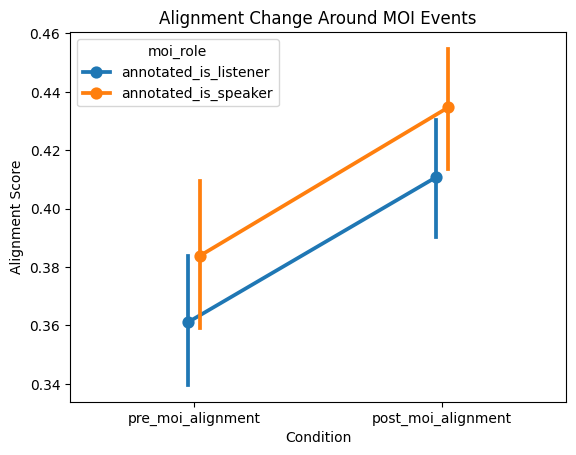

In [27]:
import seaborn as sns
test_data = df_all.copy()

test_data = test_data[
    ["session_name", "pair_id", "phase", "alignment_score", "moi_role"]
].dropna()

test_data = test_data.rename(
    columns={
        "session_name": "Session-ID",
        "pair_id": "Pair-Session-ID",
        "phase": "Condition",
        "alignment_score": "Difference",
    }
)

test_data["Condition"] = pd.Categorical(
    test_data["Condition"],
    categories=["pre_moi_alignment", "post_moi_alignment"]
)

test_data["moi_role"] = pd.Categorical(
    test_data["moi_role"],
    categories=["annotated_is_listener", "annotated_is_speaker"]
)

sns.pointplot(
    data=test_data,
    x="Condition",
    y="Difference",
    hue="moi_role",
    dodge=True,
    errorbar=("ci", 95)
)

plt.title("Alignment Change Around MOI Events")
plt.ylabel("Alignment Score")
plt.show()
